# Figure 6 — Myeloid & Macrophage Analysis
**Paper:** Biermann et al. 2022 *Cell*  
**Original code:** `Myeloid_analysis/myeloid_umap_violin_diffusion.R`, `microglia_diffusion_pathways.R`, `dendritic_diffusion.R`

| Panel | Content |
|-------|---------|
| 6A | Myeloid cell UMAP (organ / fine subtype) |
| 6B | Microglia vs MDM marker violin plots |
| 6C | M1 vs M2 polarisation score scatter |
| 6D | MBM myeloid cells more immunosuppressive (M2) |
| 6E | Microglia diffusion map (homeostatic → disease-associated) |
| 6F | Pathway enrichment in MBM vs MPM myeloid cells |
| 6G | Myeloid composition: MBM vs MPM |

## 0 · Setup

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import seaborn as sns, scanpy as sc, os
from scipy import stats
np.random.seed(42)
sc.settings.verbosity = 1
sc.settings.set_figure_params(dpi=100, facecolor='white')
os.makedirs('outputs', exist_ok=True)

COL_ORGAN = {'Brain':'#A80D11','Peripheral':'#008DB8'}
MYE_COLORS = {
    'Microglia':'#BCBD22','MDM':'#FF7F0E','cDC2':'#FFBB78',
}
print('Setup complete.')

Setup complete.


## 1 · Load & Subset Myeloid Cells

In [2]:
if os.path.exists('outputs/adata_immune_fig4.h5ad'):
    adata_all = sc.read_h5ad('outputs/adata_immune_fig4.h5ad')
else:
    if not os.path.exists('data/mbpm_immune_synthetic.h5ad'):
        exec(open('generate_immune_data.py').read())
    adata_all = sc.read_h5ad('data/mbpm_immune_synthetic.h5ad')
    sc.pp.normalize_total(adata_all, target_sum=1e4)
    sc.pp.log1p(adata_all)
    adata_all.raw = adata_all

adata_m = adata_all[adata_all.obs['cell_type_main']=='Myeloid cells'].copy()
print(f'Myeloid cells: {adata_m.n_obs:,}')
print(adata_m.obs['cell_type_fine'].value_counts().to_string())

Myeloid cells: 2,280
cell_type_fine
Microglia    1080
MDM           840
cDC2          360


## 2 · Myeloid Cell UMAP

In [3]:
_max = adata_m.X.max() if hasattr(adata_m.X,'max') else adata_m.X.toarray().max()
if _max > 50:
    sc.pp.normalize_total(adata_m, target_sum=1e4)
    sc.pp.log1p(adata_m)
if adata_m.raw is None: adata_m.raw = adata_m

sc.pp.highly_variable_genes(adata_m, n_top_genes=min(2000, adata_m.n_vars-1))
sc.pp.scale(adata_m, max_value=10)
sc.tl.pca(adata_m, n_comps=min(50, adata_m.n_obs-2), use_highly_variable=True)

import harmonypy as hm
ho = hm.run_harmony(adata_m.obsm['X_pca'], adata_m.obs, ['patient'],
                    random_state=42, verbose=False)
adata_m.obsm['X_pca_harmony'] = ho.Z_corr
sc.pp.neighbors(adata_m, use_rep='X_pca_harmony', n_pcs=20, random_state=42)
sc.tl.umap(adata_m, spread=1.5, min_dist=0.1, random_state=42)
print('Myeloid UMAP done.')

Myeloid UMAP done.


## 3 · Fig 6A — Myeloid UMAP Panels

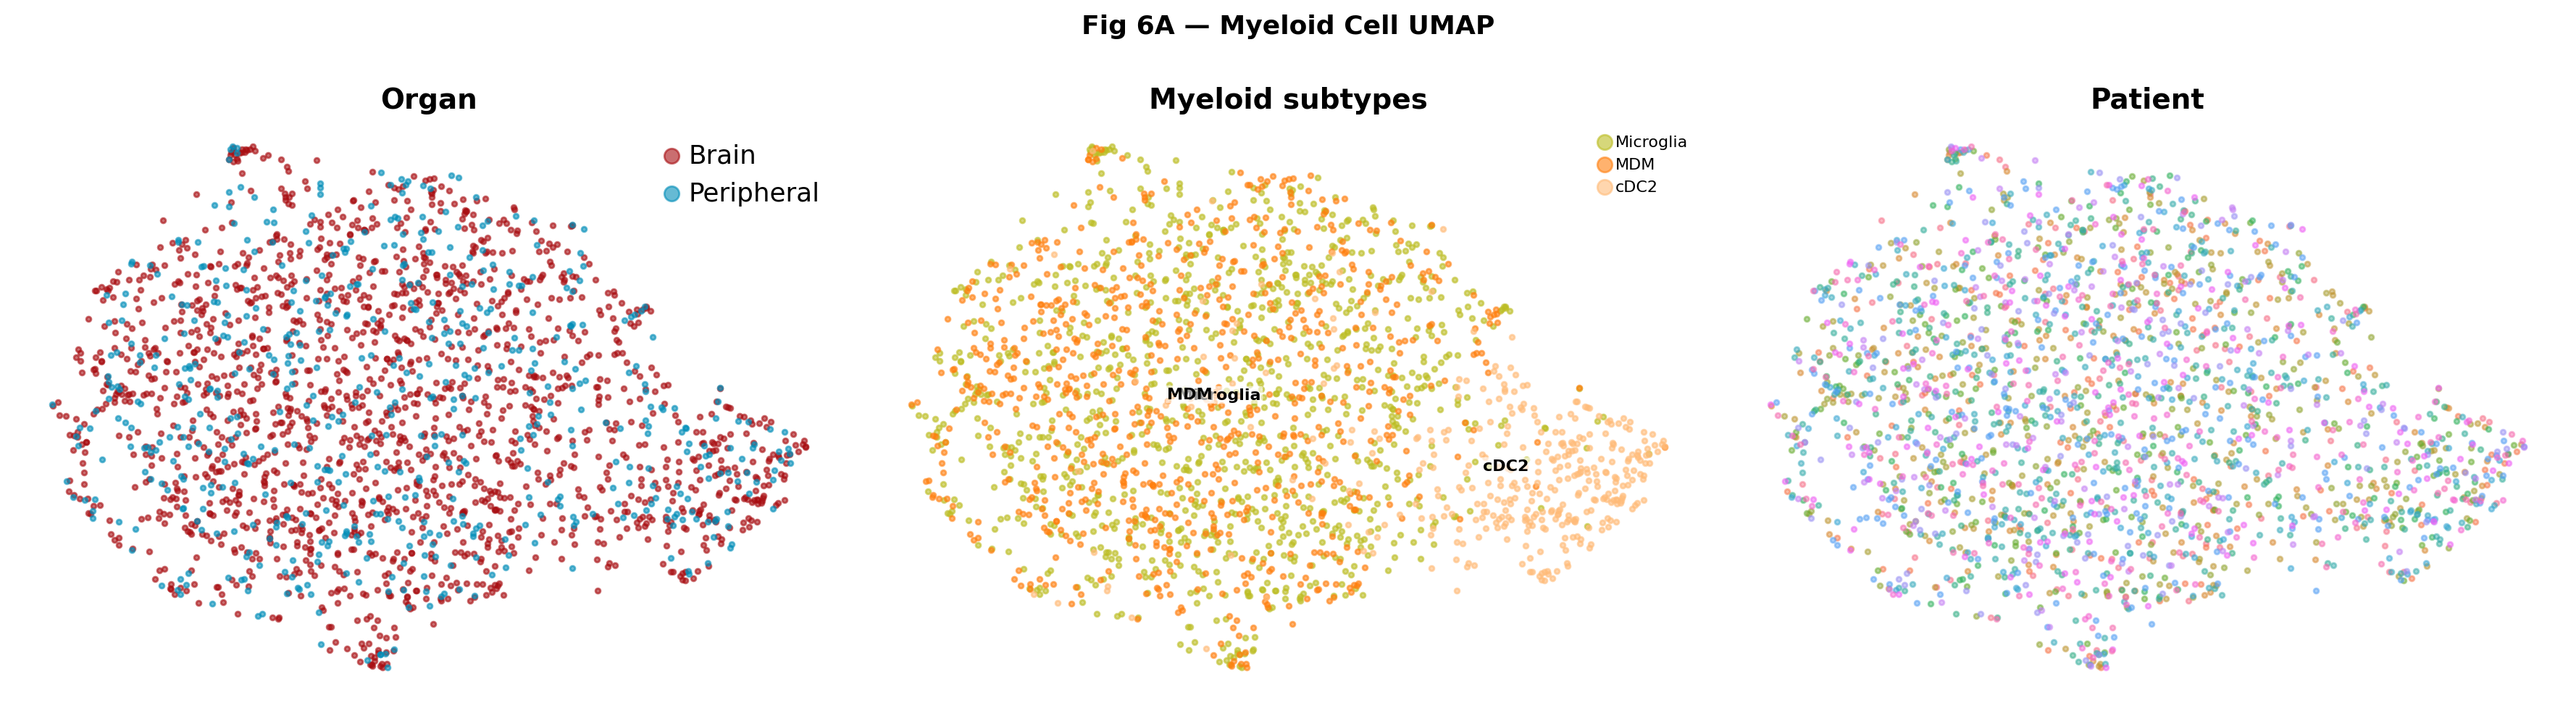

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

for org, col in COL_ORGAN.items():
    mask = adata_m.obs['organ'] == org
    axes[0].scatter(adata_m.obsm['X_umap'][mask,0], adata_m.obsm['X_umap'][mask,1],
                   c=col, s=6, alpha=0.6, label=org, rasterized=True)
axes[0].set_title('Organ', fontweight='bold'); axes[0].axis('off')
axes[0].legend(markerscale=3, frameon=False)

for ct, col in MYE_COLORS.items():
    mask = adata_m.obs['cell_type_fine'] == ct
    if mask.sum()==0: continue
    axes[1].scatter(adata_m.obsm['X_umap'][mask,0], adata_m.obsm['X_umap'][mask,1],
                   c=col, s=6, alpha=0.6, label=ct, rasterized=True)
    cx = adata_m.obsm['X_umap'][mask,0].mean()
    cy = adata_m.obsm['X_umap'][mask,1].mean()
    axes[1].text(cx, cy, ct, fontsize=8, fontweight='bold', ha='center',
                bbox=dict(boxstyle='round,pad=0.1',fc='white',alpha=0.6,lw=0))
axes[1].set_title('Myeloid subtypes', fontweight='bold'); axes[1].axis('off')
axes[1].legend(markerscale=3, frameon=False, fontsize=8)

patients = adata_m.obs['patient'].unique()
pal = sns.color_palette('husl', len(patients))
for pat, col in zip(patients, pal):
    mask = adata_m.obs['patient'] == pat
    axes[2].scatter(adata_m.obsm['X_umap'][mask,0], adata_m.obsm['X_umap'][mask,1],
                   c=[col], s=6, alpha=0.5, rasterized=True)
axes[2].set_title('Patient', fontweight='bold'); axes[2].axis('off')

plt.suptitle('Fig 6A — Myeloid Cell UMAP', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/Fig6A_myeloid_umap.pdf', bbox_inches='tight')
plt.show()

## 4 · Fig 6B — Microglia vs MDM Marker Violins
Mirrors the violin plots from `myeloid_umap_violin_diffusion.R`.

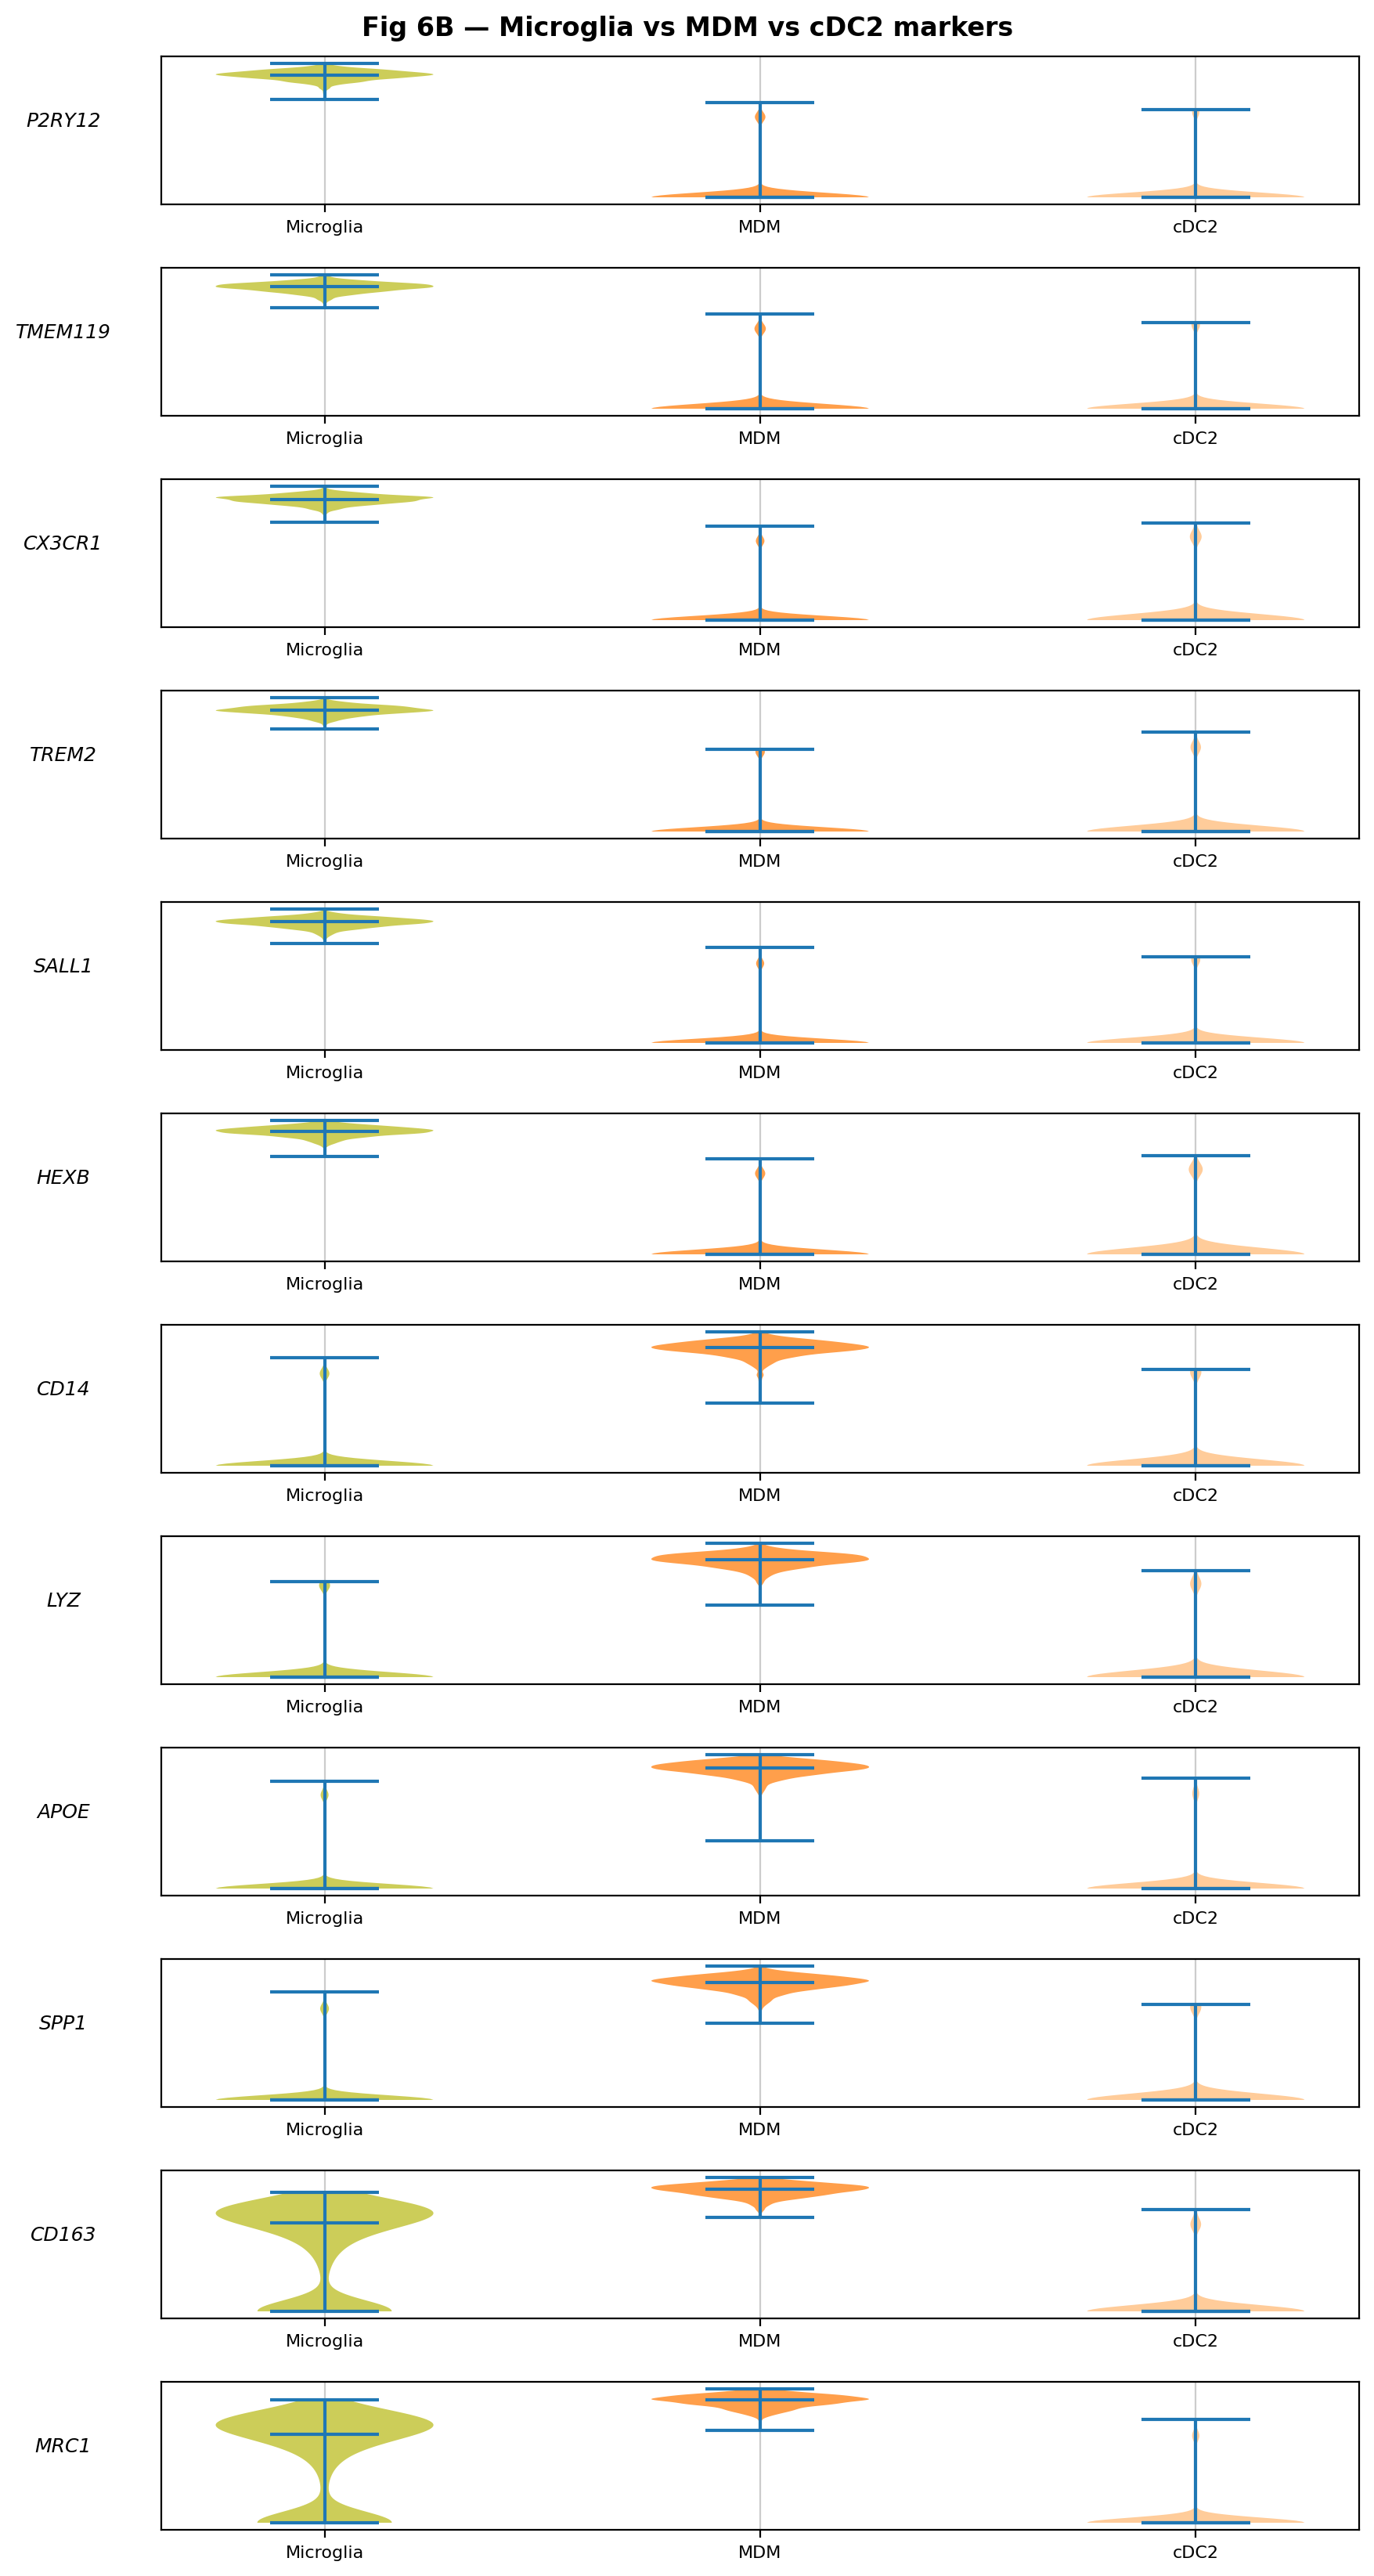

In [5]:
micro_markers = ['P2RY12','TMEM119','CX3CR1','TREM2','SALL1','HEXB']
mdm_markers   = ['CD14','LYZ','APOE','SPP1','CD163','MRC1']
all_mye_markers = micro_markers + mdm_markers
all_mye_markers = [g for g in all_mye_markers if g in adata_m.raw.var_names]

tmp_m = adata_m.raw.to_adata()
subtypes_m = ['Microglia','MDM','cDC2']

fig, axes = plt.subplots(len(all_mye_markers), 1, figsize=(9, len(all_mye_markers)*1.4))
if len(all_mye_markers)==1: axes=[axes]

for ax, gene in zip(axes, all_mye_markers):
    data_by_ct, labels, colors = [], [], []
    for ct in subtypes_m:
        mask = adata_m.obs['cell_type_fine'] == ct
        if mask.sum()==0: continue
        expr = tmp_m[mask, gene].X
        if hasattr(expr,'toarray'): expr=expr.toarray().flatten()
        else: expr=np.array(expr).flatten()
        data_by_ct.append(expr); labels.append(ct)
        colors.append(MYE_COLORS.get(ct,'#888888'))
    if data_by_ct:
        vp = ax.violinplot(data_by_ct, positions=range(len(data_by_ct)), showmedians=True)
        for body, col in zip(vp['bodies'], colors):
            body.set_facecolor(col); body.set_alpha(0.75)
        ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, fontsize=8)
        ax.set_ylabel(gene, fontsize=9, fontstyle='italic', rotation=0, labelpad=45)
        ax.tick_params(left=False); ax.set_yticks([])

plt.suptitle('Fig 6B — Microglia vs MDM vs cDC2 markers', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/Fig6B_myeloid_markers.pdf', bbox_inches='tight')
plt.show()

## 5 · Fig 6C/D — M1 vs M2 Polarisation & MBM Immunosuppression

M1 genes: ['TNF', 'IL6', 'IL12B', 'CXCL10', 'IDO1', 'NOS2', 'CCL2', 'STAT1']
M2 genes: ['MRC1', 'CD163', 'ARG1', 'CHI3L1', 'TGFB1', 'IL10', 'CCL18', 'VEGFA']
MBM M2 median = 4.4707, MPM = 0.5112
Wilcoxon (MBM > MPM): p = 0.000e+00


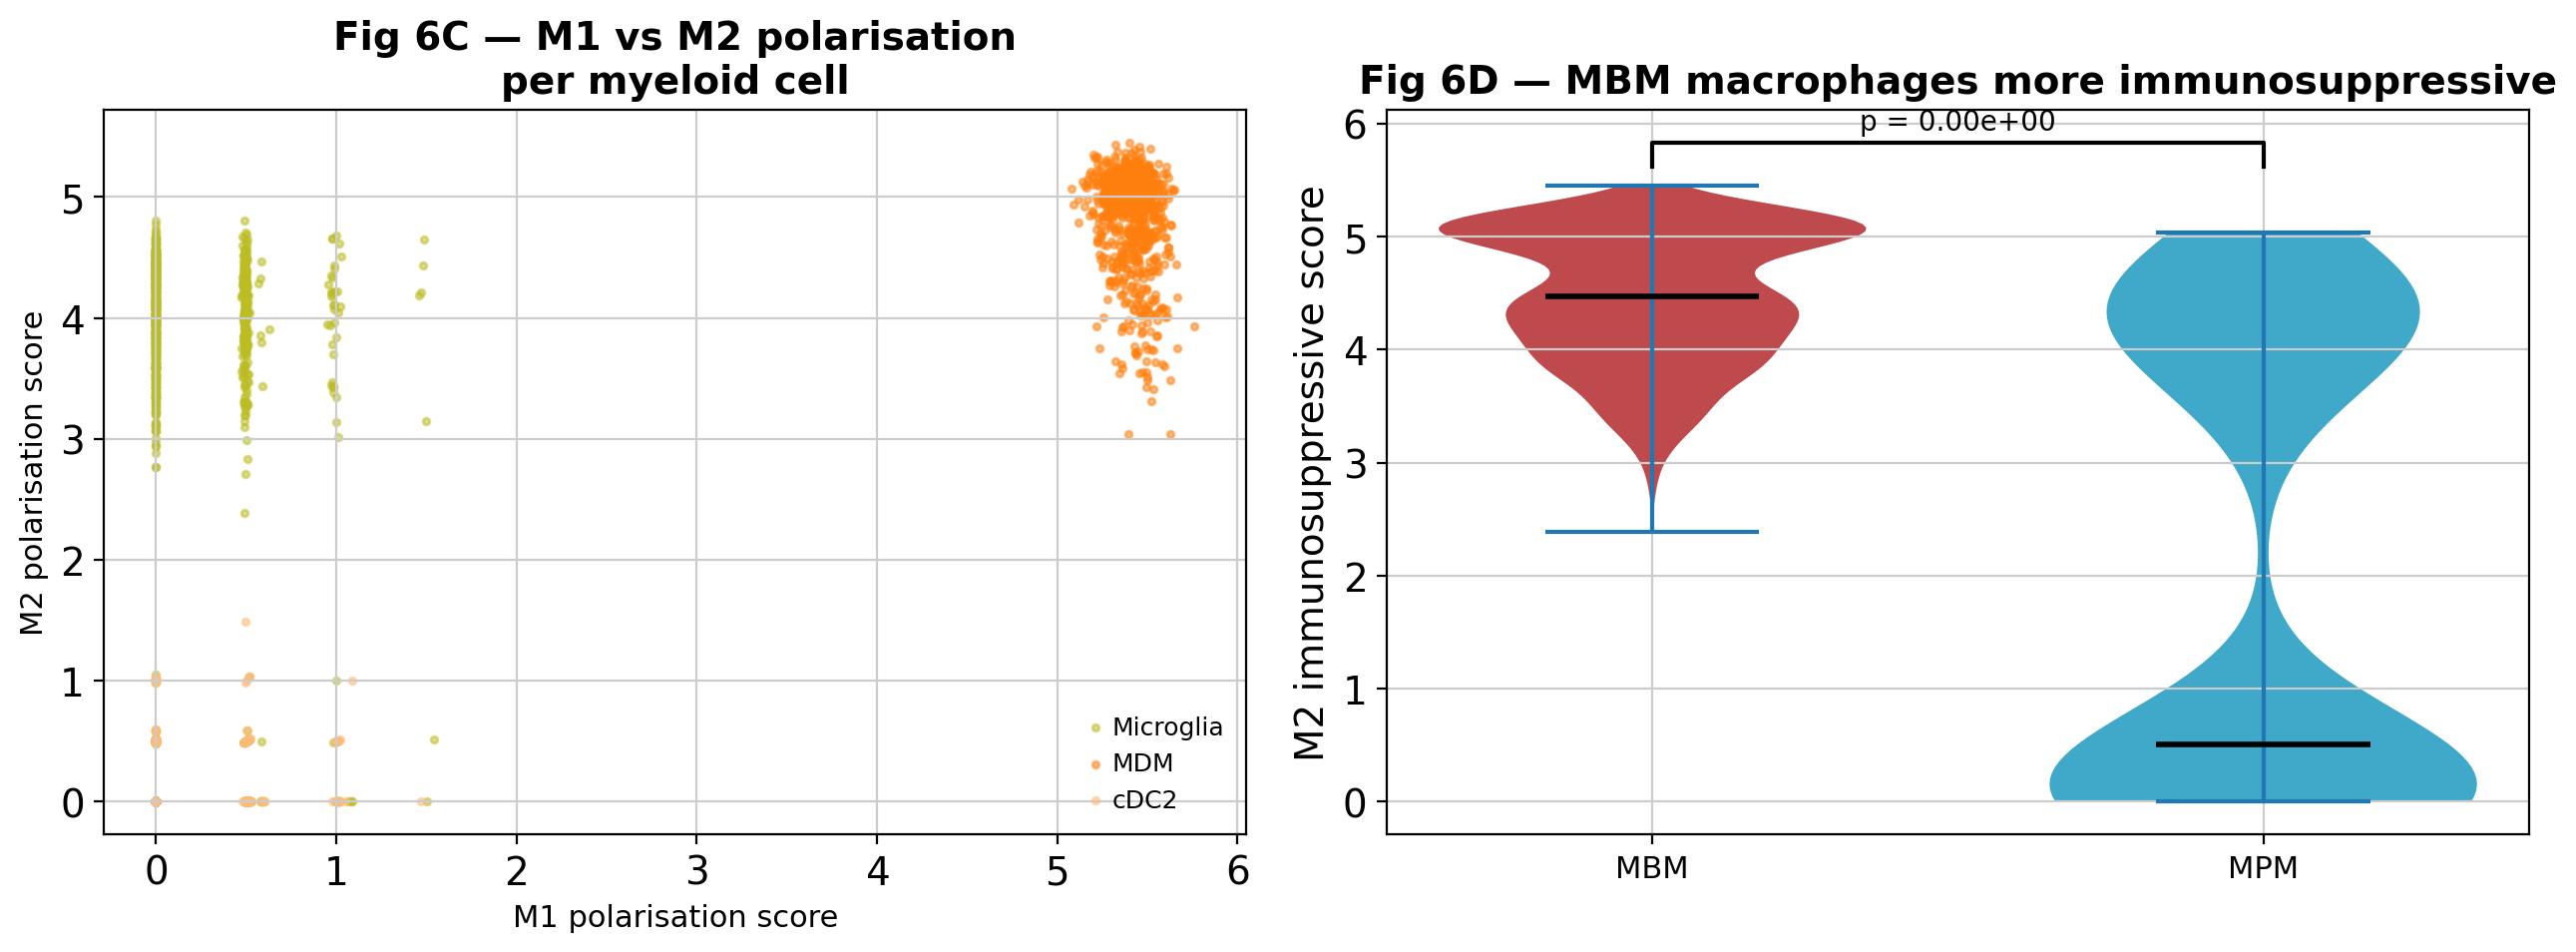

In [6]:
m1_genes = adata_m.uns.get('m1_genes',['TNF','IL6','CXCL10','IDO1','CCL2','STAT1'])
m2_genes = adata_m.uns.get('m2_genes',['MRC1','CD163','ARG1','IL10','TGFB1','CHI3L1'])
m1_genes = [g for g in m1_genes if g in adata_m.raw.var_names]
m2_genes = [g for g in m2_genes if g in adata_m.raw.var_names]
print(f'M1 genes: {m1_genes}')
print(f'M2 genes: {m2_genes}')

tmp_m2 = adata_m.raw.to_adata()
m1_score = tmp_m2[:, m1_genes].to_df().mean(axis=1)
m2_score = tmp_m2[:, m2_genes].to_df().mean(axis=1)
adata_m.obs['m1_score'] = m1_score.values
adata_m.obs['m2_score'] = m2_score.values

fig, axes = plt.subplots(1, 2, figsize=(13,5))

# Scatter: M1 vs M2 per cell coloured by subtype
for ct, col in MYE_COLORS.items():
    mask = adata_m.obs['cell_type_fine'] == ct
    if mask.sum()==0: continue
    axes[0].scatter(m1_score[mask], m2_score[mask],
                   c=col, s=6, alpha=0.5, label=ct, rasterized=True)
axes[0].set_xlabel('M1 polarisation score', fontsize=11)
axes[0].set_ylabel('M2 polarisation score', fontsize=11)
axes[0].set_title('Fig 6C — M1 vs M2 polarisation\nper myeloid cell', fontweight='bold')
axes[0].legend(frameon=False, fontsize=9)

# M2 score: MBM vs MPM (macrophages only)
mac_mask = adata_m.obs['cell_type_fine'].isin(['MDM','Microglia'])
mbm_m2 = m2_score[mac_mask & (adata_m.obs['organ']=='Brain')]
mpm_m2 = m2_score[mac_mask & (adata_m.obs['organ']=='Peripheral')]
stat, p = stats.mannwhitneyu(mbm_m2, mpm_m2, alternative='greater')
print(f'MBM M2 median = {mbm_m2.median():.4f}, MPM = {mpm_m2.median():.4f}')
print(f'Wilcoxon (MBM > MPM): p = {p:.3e}')

vp = axes[1].violinplot([mbm_m2.values, mpm_m2.values], positions=[0,1],
                         showmedians=True, widths=0.7)
for body,col in zip(vp['bodies'],['#A80D11','#008DB8']):
    body.set_facecolor(col); body.set_alpha(0.75)
vp['cmedians'].set_color('black'); vp['cmedians'].set_linewidth(2)
y_top = max(mbm_m2.max(), mpm_m2.max())
axes[1].plot([0,0,1,1],[y_top*1.03,y_top*1.07,y_top*1.07,y_top*1.03],'k-',lw=1.5)
axes[1].text(0.5, y_top*1.09, f'p = {p:.2e}', ha='center', fontsize=10)
axes[1].set_xticks([0,1]); axes[1].set_xticklabels(['MBM','MPM'], fontsize=11)
axes[1].set_ylabel('M2 immunosuppressive score')
axes[1].set_title('Fig 6D — MBM macrophages more immunosuppressive', fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/Fig6CD_M1_M2.pdf', bbox_inches='tight')
plt.show()

## 6 · Fig 6E — Microglia Diffusion Map
Mirrors `microglia_diffusion_pathways.R` — homeostatic vs disease-associated microglia trajectory.

Microglia: 1080


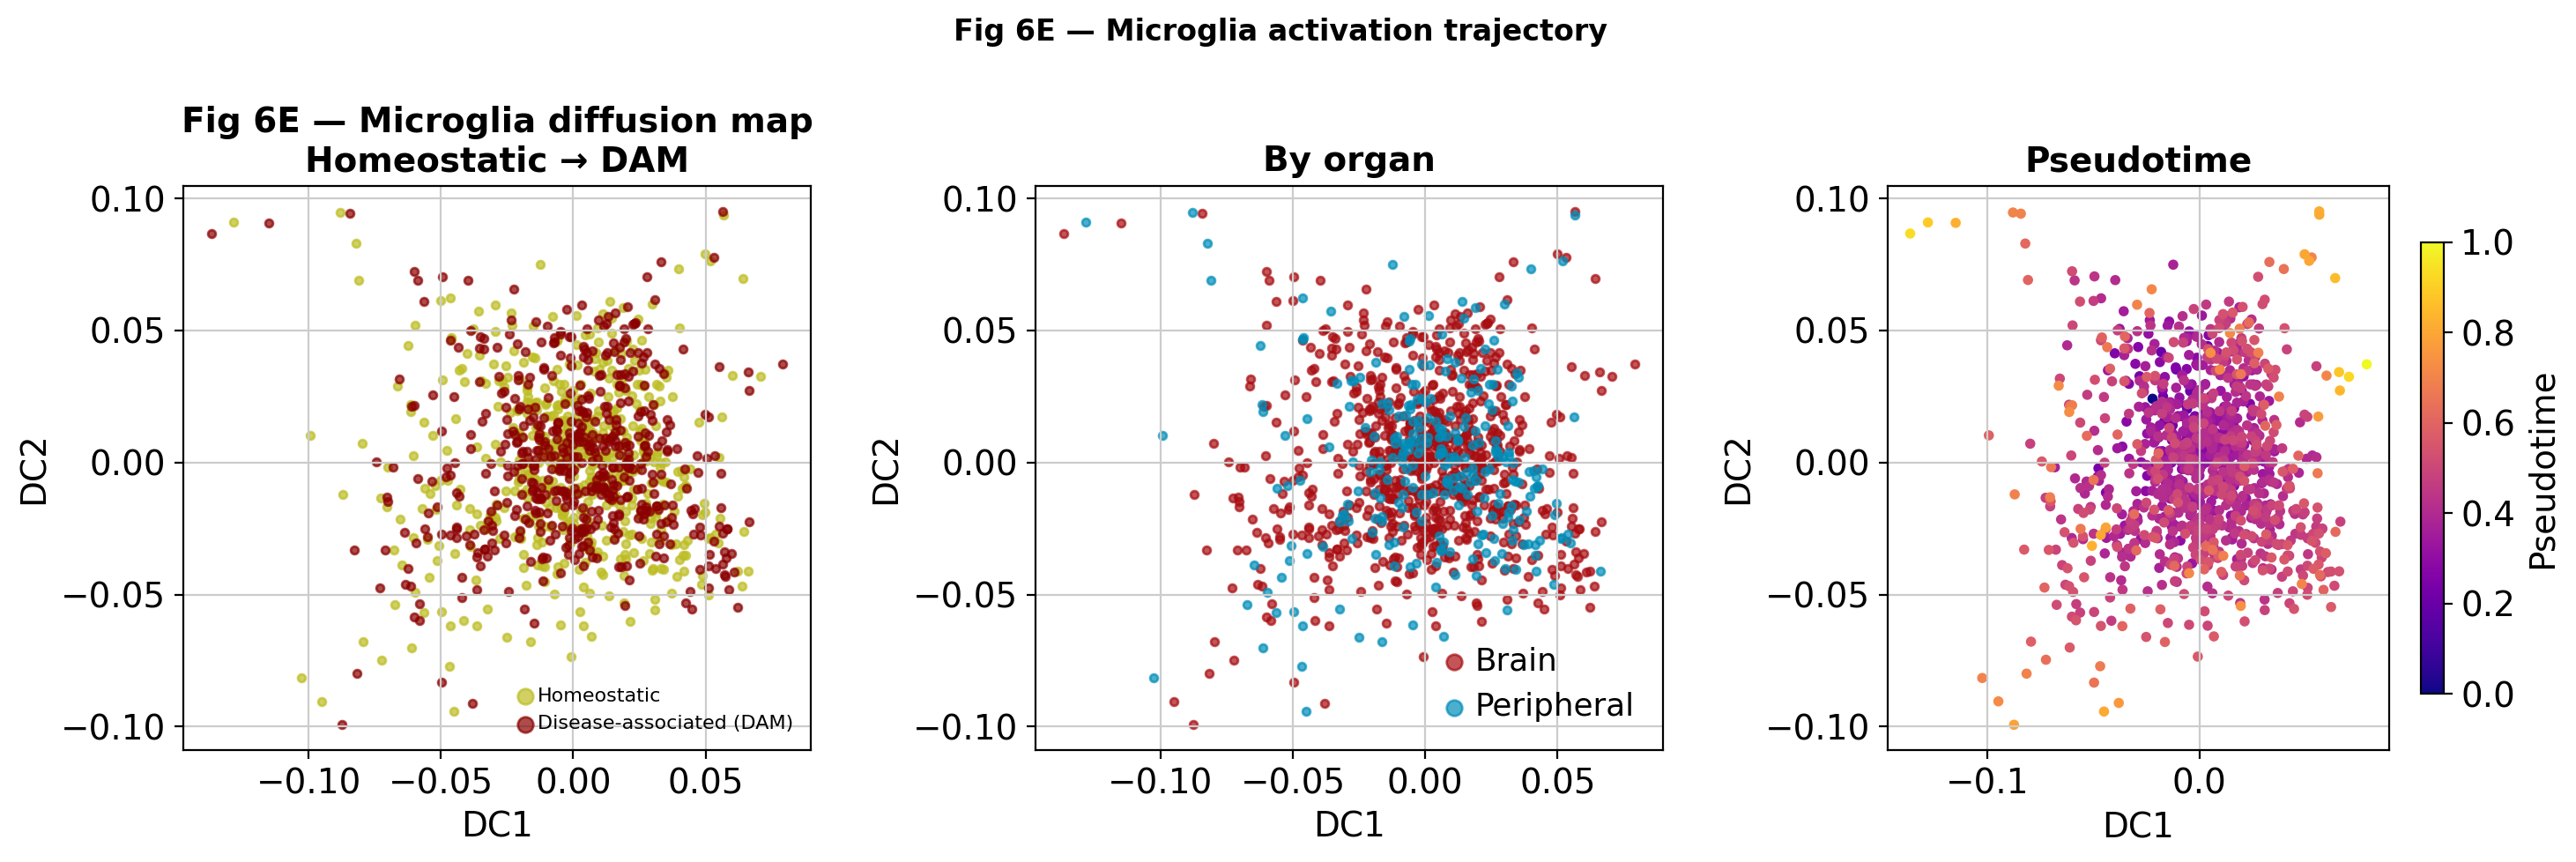

In [7]:
micro_mask = adata_m.obs['cell_type_fine'] == 'Microglia'
micro = adata_m[micro_mask].copy()
print(f'Microglia: {micro.n_obs}')

sc.pp.neighbors(micro, use_rep='X_pca_harmony' if 'X_pca_harmony' in micro.obsm else 'X_pca',
                n_pcs=min(20, micro.n_obs-2), random_state=42)
sc.tl.diffmap(micro, n_comps=10)
micro.uns['iroot'] = 0
sc.tl.dpt(micro)

# Label homeostatic vs disease-associated microglia by M2 score
micro.obs['micro_state'] = np.where(
    micro.obs['m2_score'] > micro.obs['m2_score'].median(),
    'Disease-associated (DAM)', 'Homeostatic'
)

fig, axes = plt.subplots(1, 3, figsize=(15,5))

for state, col in [('Homeostatic','#BCBD22'),('Disease-associated (DAM)','#8B0000')]:
    mask = micro.obs['micro_state'] == state
    axes[0].scatter(micro.obsm['X_diffmap'][mask,1], micro.obsm['X_diffmap'][mask,2],
                   c=col, s=10, alpha=0.7, label=state, rasterized=True)
axes[0].set_xlabel('DC1'); axes[0].set_ylabel('DC2')
axes[0].set_title('Fig 6E — Microglia diffusion map\nHomeostatic → DAM', fontweight='bold')
axes[0].legend(markerscale=2, frameon=False, fontsize=8)

for org, col in COL_ORGAN.items():
    mask = micro.obs['organ'] == org
    axes[1].scatter(micro.obsm['X_diffmap'][mask,1], micro.obsm['X_diffmap'][mask,2],
                   c=col, s=10, alpha=0.7, label=org, rasterized=True)
axes[1].set_xlabel('DC1'); axes[1].set_ylabel('DC2')
axes[1].set_title('By organ', fontweight='bold')
axes[1].legend(markerscale=2, frameon=False)

order = np.argsort(micro.obs['dpt_pseudotime'].values)
sc4 = axes[2].scatter(micro.obsm['X_diffmap'][order,1], micro.obsm['X_diffmap'][order,2],
                      c=micro.obs['dpt_pseudotime'].values[order],
                      cmap='plasma', s=10, rasterized=True)
plt.colorbar(sc4, ax=axes[2], label='Pseudotime', shrink=0.8)
axes[2].set_xlabel('DC1'); axes[2].set_ylabel('DC2')
axes[2].set_title('Pseudotime', fontweight='bold')

plt.suptitle('Fig 6E — Microglia activation trajectory', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/Fig6E_microglia_diffusion.pdf', bbox_inches='tight')
plt.show()

## 7 · Fig 6F — Pathway Enrichment in Myeloid Cells (MBM vs MPM)

In [8]:
# DEG: MBM vs MPM myeloid cells
adata_m.obs['organ_cat'] = adata_m.obs['organ'].astype('category')
sc.tl.rank_genes_groups(adata_m, groupby='organ_cat', groups=['Brain'],
                        reference='Peripheral', method='wilcoxon', use_raw=True)
mye_res = sc.get.rank_genes_groups_df(adata_m, group='Brain')
mye_res.columns = ['gene','log2FC','score','pval','pval_adj']
mye_res = mye_res.dropna()

PATHWAYS_MYE = {
    'COMPLEMENT':          ['C1QA','C1QB','C3','CFB','CFH','ITGAM'],
    'PHAGOCYTOSIS':        ['CD68','FCGR1A','FCGR3A','MSR1','MARCO','SIGLEC1'],
    'ANTI_INFLAMMATORY':   ['MRC1','CD163','IL10','TGFB1','ARG1','CHI3L1'],
    'PROINFLAMMATORY':     ['TNF','IL6','IL12B','CXCL10','NOS2','IDO1'],
    'OXIDATIVE_PHOSPH':    ['SDHA','COX5A','ATP5F1B','UQCRH','NDUFS1'],
    'LIPID_METABOLISM':    ['APOE','APOC1','FABP5','LPL','CD36','PPARG'],
    'DAM_PROGRAM':         ['TREM2','TMEM119','P2RY12','SPP1','LPL','CST7'],
    'ANTIGEN_PRESENTATION':['HLA-DRA','HLA-DRB1','CD80','CD86','CD1C','FCER1A'],
}
mye_sorted = mye_res.set_index('gene')['log2FC'].sort_values(ascending=False)
gsea_rows = []
for pw, genes in PATHWAYS_MYE.items():
    genes_in = [g for g in genes if g in mye_sorted.index]
    if not genes_in: continue
    mean_fc = mye_sorted.loc[genes_in].mean()
    bg_std  = mye_sorted.std()
    nes     = mean_fc/(bg_std+1e-9)
    perms   = [mye_sorted.sample(len(genes_in)).mean() for _ in range(300)]
    p_perm  = (np.array(perms)>=mean_fc).mean() if nes>0 else (np.array(perms)<=mean_fc).mean()
    gsea_rows.append({'pathway':pw,'NES':round(nes,3),'p':round(p_perm,3),
                      'direction':'MBM-enriched' if nes>0 else 'MPM-enriched'})
gsea_mye = pd.DataFrame(gsea_rows).sort_values('NES')
print(gsea_mye.to_string(index=False))

             pathway    NES     p    direction
         DAM_PROGRAM -1.256 0.000 MPM-enriched
    LIPID_METABOLISM -1.107 0.007 MPM-enriched
     PROINFLAMMATORY -0.900 0.000 MPM-enriched
          COMPLEMENT -0.428 0.023 MPM-enriched
        PHAGOCYTOSIS -0.161 0.353 MPM-enriched
ANTIGEN_PRESENTATION  0.185 0.087 MBM-enriched
   ANTI_INFLAMMATORY 15.757 0.000 MBM-enriched


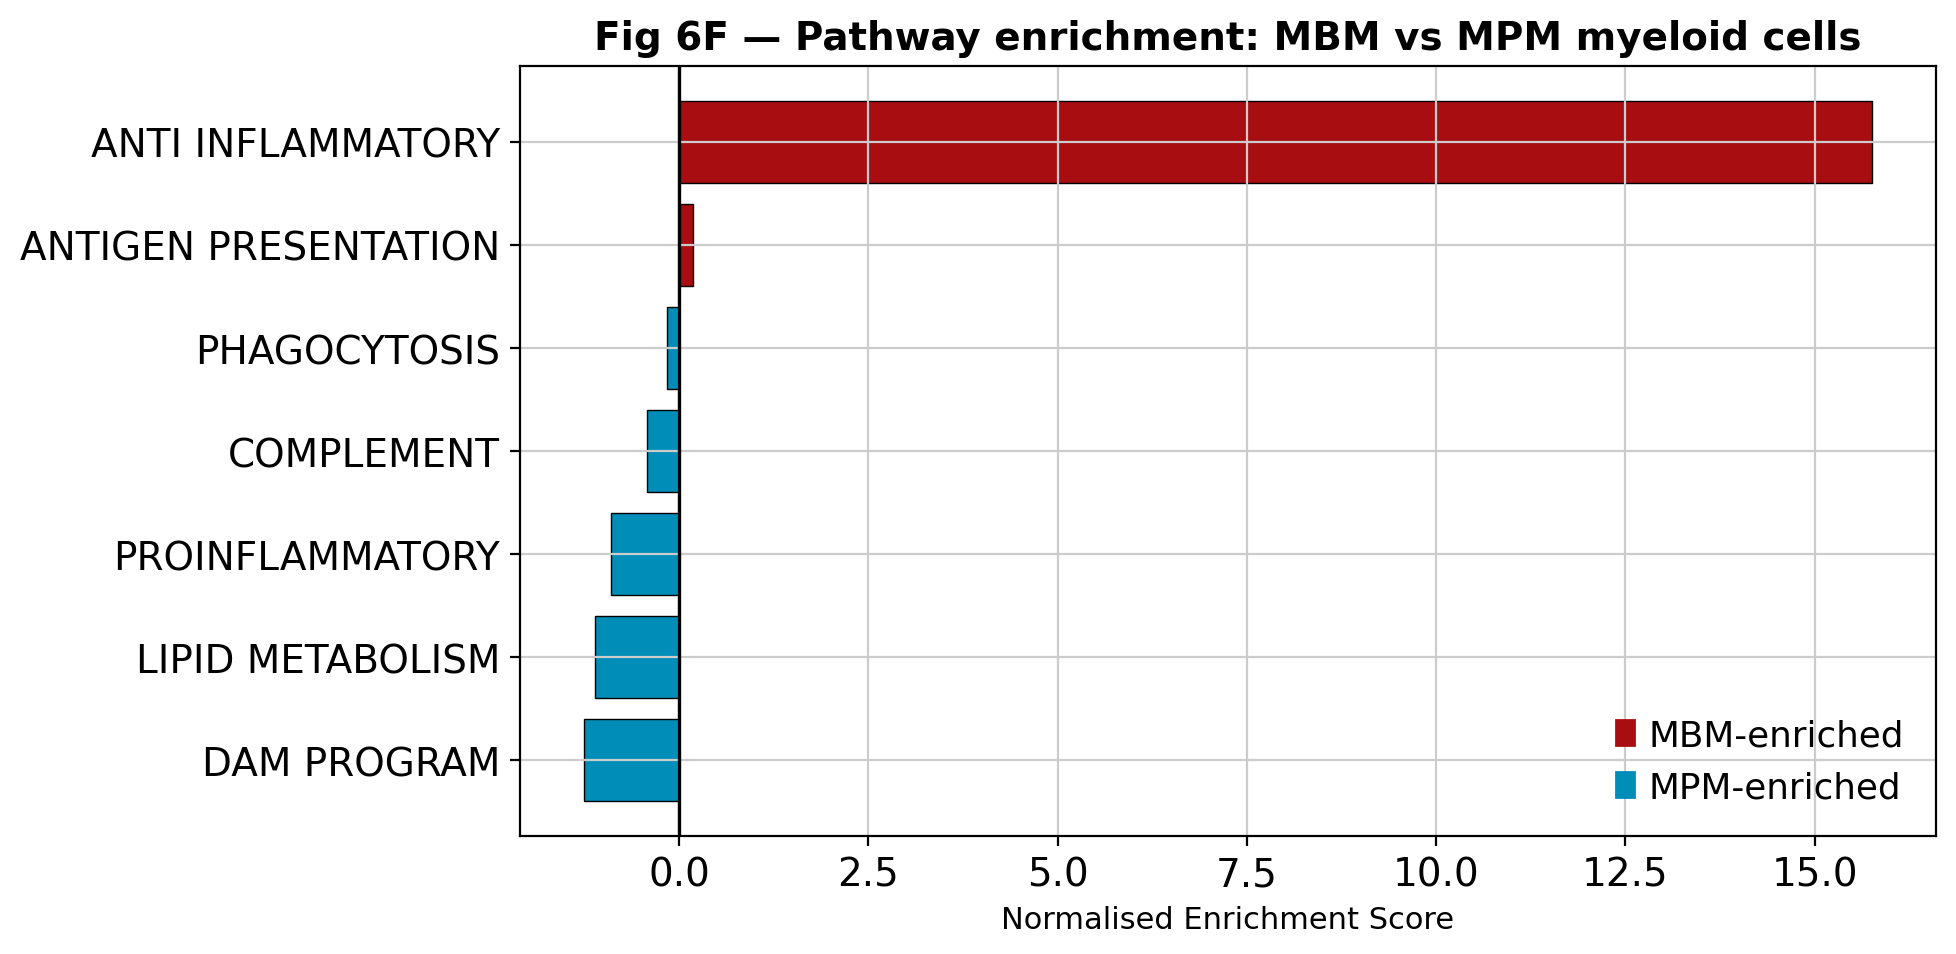

In [9]:
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(10,5))
cols = gsea_mye['direction'].map({'MBM-enriched':'#A80D11','MPM-enriched':'#008DB8'})
ax.barh(gsea_mye['pathway'].str.replace('_',' '), gsea_mye['NES'],
        color=cols, edgecolor='black', linewidth=0.5)
ax.axvline(0, color='black', lw=1.2)
ax.legend(handles=[Patch(color='#A80D11',label='MBM-enriched'),
                   Patch(color='#008DB8',label='MPM-enriched')], frameon=False)
ax.set_xlabel('Normalised Enrichment Score', fontsize=11)
ax.set_title('Fig 6F — Pathway enrichment: MBM vs MPM myeloid cells', fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/Fig6F_myeloid_pathways.pdf', bbox_inches='tight')
plt.show()
gsea_mye.to_csv('outputs/GSEA_myeloid_MBM_vs_MPM.csv', index=False)

## 8 · Fig 6G — Myeloid Composition: MBM vs MPM

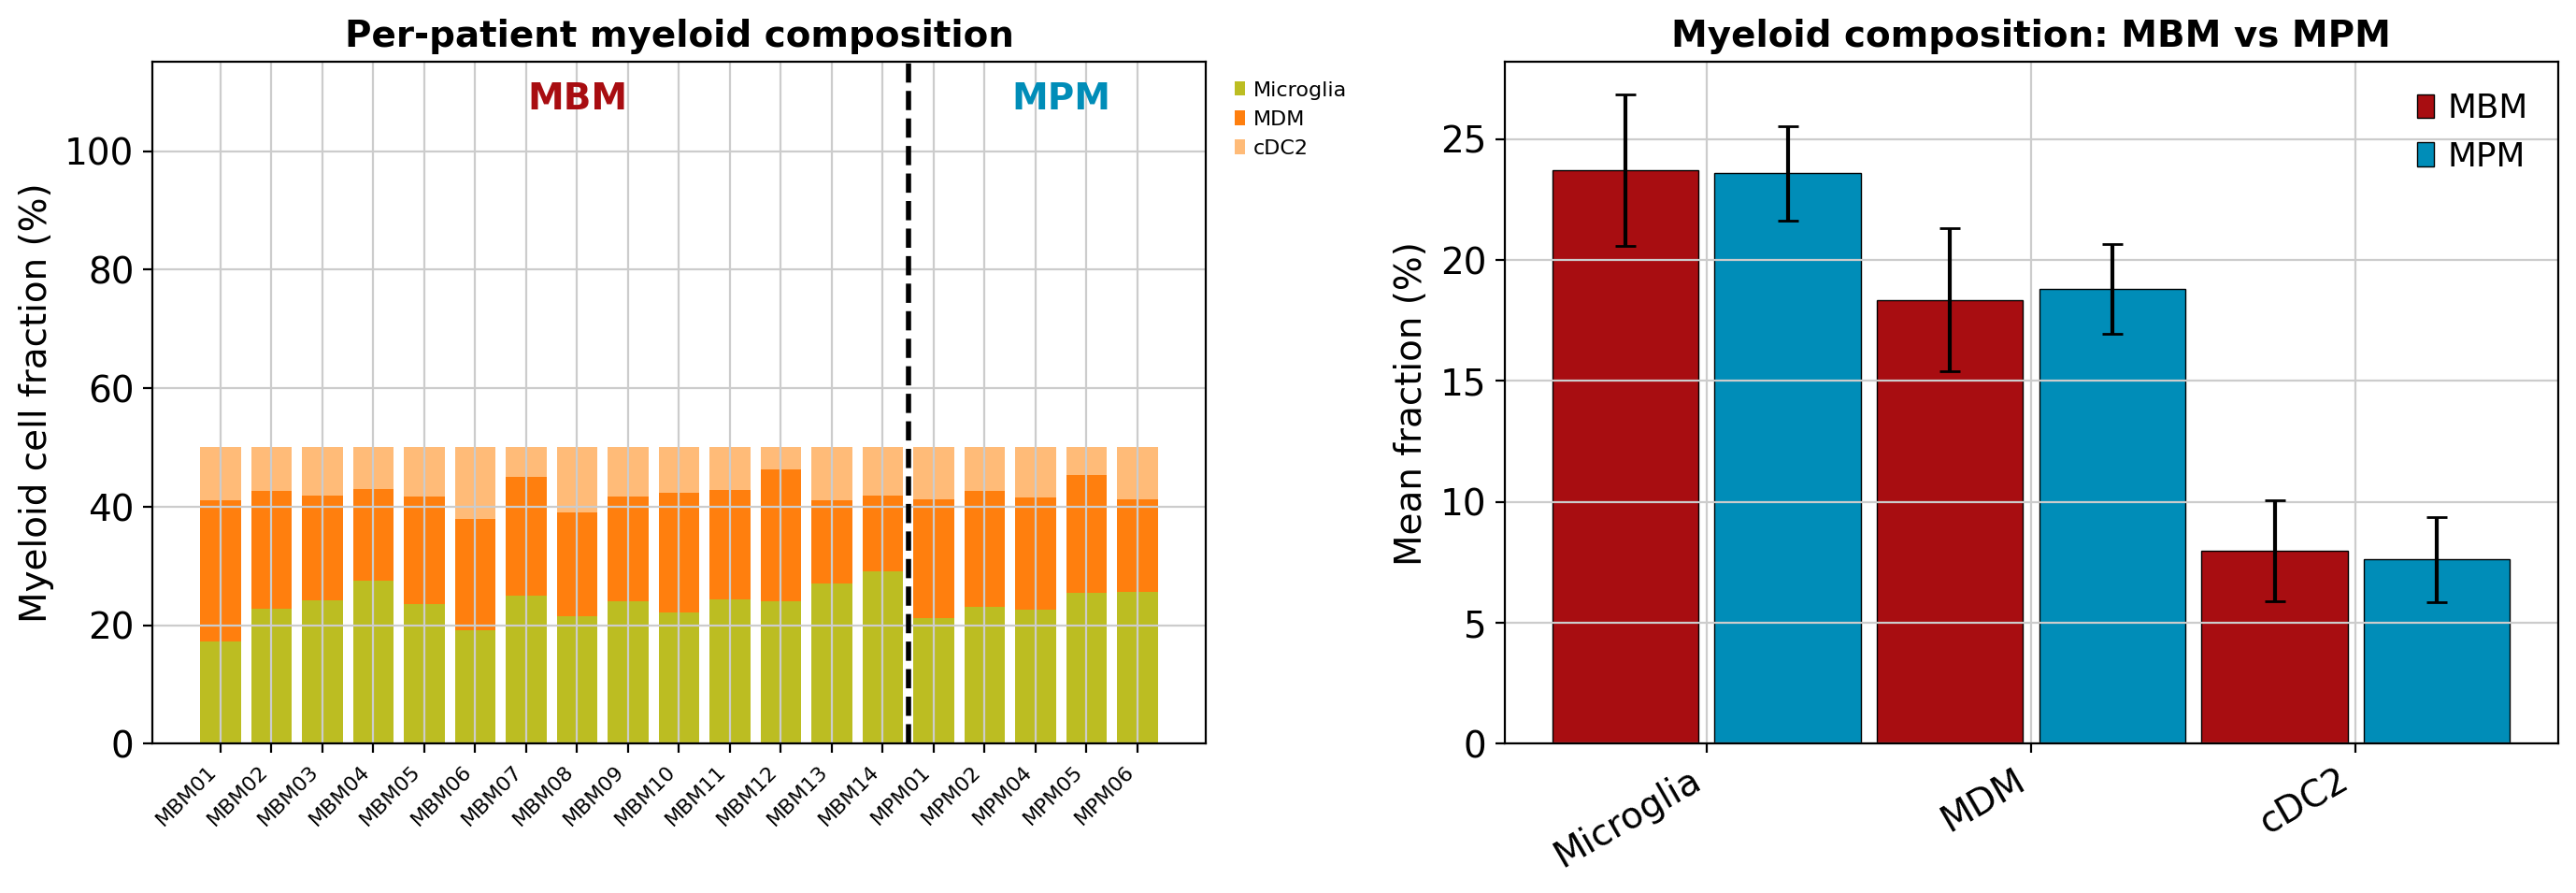

In [10]:
comp_m = (adata_m.obs.groupby(['patient','organ','cell_type_fine'])
          .size().reset_index(name='n'))
comp_m['pct'] = comp_m.groupby('patient')['n'].transform(lambda x: x/x.sum()*100)
piv_m = comp_m.pivot_table(index='patient', columns='cell_type_fine', values='pct', fill_value=0)
piv_m.columns = [str(c) for c in piv_m.columns]; piv_m.columns.name = None
meta_m = adata_m.obs[['patient','organ']].drop_duplicates().set_index('patient')
piv_m = piv_m.join(meta_m).sort_values(['organ','patient'])

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Stacked bar per patient
bottom = np.zeros(len(piv_m))
for ct, col in MYE_COLORS.items():
    if ct not in piv_m.columns: continue
    axes[0].bar(range(len(piv_m)), piv_m[ct], bottom=bottom, color=col, label=ct, width=0.8)
    bottom += piv_m[ct].values

n_brain = (piv_m['organ']=='Brain').sum()
axes[0].axvline(n_brain-0.5, color='black', lw=2, ls='--')
axes[0].text(n_brain/2, 107, 'MBM', ha='center', fontweight='bold', color='#A80D11')
axes[0].text(n_brain+(len(piv_m)-n_brain)/2, 107, 'MPM', ha='center', fontweight='bold', color='#008DB8')
axes[0].set_xticks(range(len(piv_m))); axes[0].set_xticklabels(piv_m.index, rotation=45, ha='right', fontsize=8)
axes[0].set_ylabel('Myeloid cell fraction (%)'); axes[0].set_ylim(0,115)
axes[0].set_title('Per-patient myeloid composition', fontweight='bold')
axes[0].legend(bbox_to_anchor=(1.01,1), frameon=False, fontsize=8)

# Summary: mean fractions MBM vs MPM
for i,(ct,col) in enumerate(MYE_COLORS.items()):
    if ct not in piv_m.columns: continue
    mbm_vals = piv_m[piv_m['organ']=='Brain'][ct]
    mpm_vals = piv_m[piv_m['organ']=='Peripheral'][ct]
    x_pos = i*0.4
    axes[1].bar(x_pos, mbm_vals.mean(), 0.18, color='#A80D11',
                yerr=mbm_vals.std(), capsize=4, edgecolor='black', lw=0.5, label='MBM' if i==0 else '')
    axes[1].bar(x_pos+0.2, mpm_vals.mean(), 0.18, color='#008DB8',
                yerr=mpm_vals.std(), capsize=4, edgecolor='black', lw=0.5, label='MPM' if i==0 else '')
axes[1].set_xticks([i*0.4+0.1 for i in range(len(MYE_COLORS))])
axes[1].set_xticklabels(list(MYE_COLORS.keys()), rotation=30, ha='right')
axes[1].set_ylabel('Mean fraction (%)')
axes[1].set_title('Myeloid composition: MBM vs MPM', fontweight='bold')
axes[1].legend(frameon=False)
plt.tight_layout()
plt.savefig('outputs/Fig6G_myeloid_composition.pdf', bbox_inches='tight')
plt.show()

## 9 · Save

In [11]:
adata_m.write_h5ad('outputs/adata_myeloid_fig6.h5ad')
print('Saved: outputs/adata_myeloid_fig6.h5ad')
print('All Figure 6 PDFs saved to outputs/')

Saved: outputs/adata_myeloid_fig6.h5ad
All Figure 6 PDFs saved to outputs/


## Key Findings
| Finding | Evidence |
|---------|----------|
| Microglia and MDM are distinct myeloid populations | Marker genes: P2RY12/TMEM119 (microglia) vs CD14/LYZ (MDM) |
| **MBM macrophages are more immunosuppressive (M2)** | M2 score Wilcoxon p<<0.05; MBM>MPM |
| DAM (disease-associated microglia) in MBM | Pseudotime trajectory; TREM2/SPP1 upregulated |
| MBM myeloid cells enriched for lipid metabolism | APOE, FABP5, LPL pathways; characteristic of DAM |
| Anti-inflammatory pathway enriched in MBM | IL-10, TGF-β, ARG1 — immunosuppressive TME |